## Step 1: Test single retailer-SKU demand

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

#Load config
with open('../config.yaml', 'r') as f:
    cfg = yaml.safe_load(f)

# Show demand section
cfg["demand"]

{'base_range_per_sku': [80, 140],
 'seasonality_amp_pct': 0.15,
 'trend_pct_per_year': 0.05,
 'noise_sd_pct': 0.1,
 'promo': {'weeks_per_store': 4, 'uplift_pct': 0.35}}

In [2]:
def generate_weekly_demand(base, weeks, seasonality_amp, trend_per_year, noise_sd, promo_weeks, uplift_pct, seed=None):
    """Generate weekly demand time series for a single SKU at one retailer"""
    if seed is not None:
        np.random.seed(seed)

    week_nums = np.arange(1, weeks + 1)

    # Seasonal pattern (sinusoidal)
    season = 1 + seasonality_amp * np.sin(2 * np.pi * week_nums / 52)

    # Trend (upward)
    trend = 1 + trend_per_year * (week_nums / 52)

    # Random noise
    noise = np.random.normal(0, base * noise_sd, weeks)

    # Promo uplift
    promo_mask = np.zeros(weeks)
    promo_indices = np.random.choice(weeks, promo_weeks, replace=False)
    promo_mask[promo_indices] = uplift_pct
    promo_multiplier = 1 + promo_mask

    # Combine all
    demand = base * season * trend * promo_multiplier + noise
    demand = np.clip(demand, 0, None)
    return pd.DataFrame({
        "week": week_nums,
        "demand_units": np.round(demand, 2)
    })


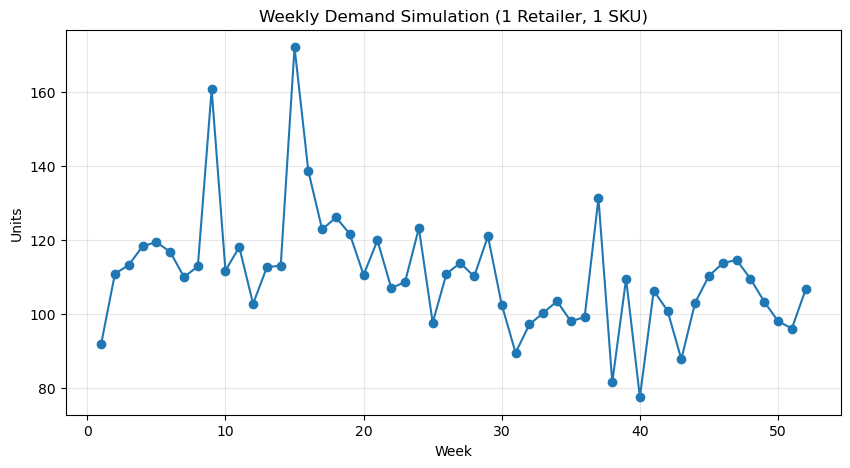

In [3]:
weeks = cfg["time"]["weeks"]
params = cfg["demand"]

df = generate_weekly_demand(
    base=np.random.randint(params["base_range_per_sku"][0], params["base_range_per_sku"][1]),
    weeks=weeks,
    seasonality_amp=params["seasonality_amp_pct"],
    trend_per_year=params["trend_pct_per_year"],
    noise_sd=params["noise_sd_pct"],
    promo_weeks=params["promo"]["weeks_per_store"],
    uplift_pct=params["promo"]["uplift_pct"],
)

plt.figure(figsize=(10,5))
plt.plot(df["week"], df["demand_units"], marker="o", color="#1f77b4")
plt.title("Weekly Demand Simulation (1 Retailer, 1 SKU)")
plt.xlabel("Week")
plt.ylabel("Units")
plt.grid(alpha=0.3)
plt.show()


## Step 2: Expand to multi-retailer multi-SKU

In [ ]:
from tqdm import tqdm  # progress bar

n_retailers = cfg["network"]["retailers"]
n_skus = cfg["network"]["skus"]
weeks = cfg["time"]["weeks"]
params = cfg["demand"]

In [ ]:
rows = []
for r in tqdm(range(n_retailers), desc="Generating demand per retailer"):
    for s in range(n_skus):
        base = np.random.randint(params["base_range_per_sku"][0], params["base_range_per_sku"][1])
        demand = generate_weekly_demand(
            base=base,
            weeks=weeks,
            seasonality_amp=params["seasonality_amp_pct"],
            trend_per_year=params["trend_pct_per_year"],
            noise_sd=params["noise_sd_pct"],
            promo_weeks=params["promo"]["weeks_per_store"],
            uplift_pct=params["promo"]["uplift_pct"],
        )
        demand["retailer_id"] = f"RET_{r+1}"
        demand["sku_id"] = f"SKU_{s+1}"
        rows.append(demand)

df = pd.concat(rows, ignore_index=True)
df.head()

In [ ]:
plt.figure(figsize=(10,6))
for sku in df["sku_id"].unique():
    subset = df[(df["retailer_id"] == "RET_1") & (df["sku_id"] == sku)]
    plt.plot(subset["week"], subset["demand_units"], label=sku)
plt.title("Weekly Demand Simulation (Retailer_1)")
plt.xlabel("Week")
plt.ylabel("Units")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
output_path = "../data/processed/demand_simulated.csv"
df.to_csv(output_path, index=False)
print(f"✅ Demand simulation saved to: {output_path}")